# Módulo 7 · Clase 1 — Lo que antes necesitaba un programador

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### Cómo se usa este cuaderno

La clase alterna dos tipos de sección:

- 🎬 **DEMO** — un mini-proyecto resuelto, con el **prompt exacto** que se le
  dio al agente y lo que salió. Ustedes lo corren y lo discutimos.
- 🛠️ **RETO** — el mismo tipo de problema, en **otro dataset**, y lo
  resuelven **ustedes** dirigiendo al agente. Solo hay pistas y preguntas.

> ⚠️ **Los retos no tienen solución escrita en ninguna parte** — ni en este
> cuaderno, ni en el repositorio. Se construyen en clase, en vivo. Así que si
> se atascan, la jugada correcta es preguntar, no buscar.

**El agente:** el panel de **Gemini** de Colab (el ícono ✨). A él le van a
copiar los prompts.

**No hace falta haber programado nunca.**

---

### El proyecto del módulo — desde ya

Este módulo se aprueba con **una aplicación que resuelva un problema real de
su trabajo**, construida dirigiendo a un agente, con su link funcionando.

- **Equipos de hasta 3 personas** (solo también vale).
- **Entrega: hasta el jueves de la próxima semana.**
- **Esta semana** se introducen las herramientas **reales** con las que se
  produce ML en la industria hoy: agentes de código, servir un modelo, apps
  que otros usan. Cada clase le suma una pieza a su proyecto.
- Se entrega con los **prompts** que usaron, **un error del agente que
  ustedes cazaron**, y qué **decisión** habilita la herramienta.

**Tarea de hoy mismo:** elijan equipo y problema. El problema correcto es
uno donde alguien pierde tiempo con una hoja de cálculo.

## 0 · Preparación

Una sola celda. Todo viene instalado en Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ¿estamos en Colab? la parte de la app lo usa al final
try:
    import google.colab          # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

print("listo. ¿en Colab?", EN_COLAB)

listo. ¿en Colab? False


## 0.1 · Las herramientas de hoy, en una frase cada una

| herramienta | qué es |
|---|---|
| **Colab** | el taller: un cuaderno de Python en el navegador, gratis |
| **Gemini** | el contratista: el agente que vive dentro de Colab |
| **pandas** | la mesa de trabajo: deja los datos en *tablas* manejables con código |
| **seaborn** | el dibujante: gráficas con las decisiones de diseño ya tomadas — y trae los datos de práctica de hoy |
| **Gradio** | la vitrina: convierte una función en una página web con un link |

## 0.2 · Los cuatro datos de hoy

Todos vienen **dentro de seaborn**: una línea y están cargados.

| dataset | qué es | quién lo trabaja |
|---|---|---|
| `taxis` | 6.433 viajes de taxi de Nueva York | 🎬 las demos |
| `mpg` | 398 vehículos, 1970–1982 | 🛠️ ustedes (reto 1) |
| `car_crashes` | accidentes viales en 51 estados | 🛠️ ustedes (reto 2) |
| `diamonds` | 53.940 diamantes con precio y medidas | 🛠️ ustedes (reto 3) |

A propósito ninguno es de petróleo: la habilidad es la misma en cualquier
dominio, y el proyecto del módulo es con **su** dato.

In [2]:
taxis = sns.load_dataset("taxis")

# preparamos las columnas de tiempo que van a usar las demos
taxis["pickup"] = pd.to_datetime(taxis.pickup)
taxis["dropoff"] = pd.to_datetime(taxis.dropoff)
taxis["hora"] = taxis.pickup.dt.hour          # 0 a 23
taxis["dia"] = taxis.pickup.dt.dayofweek      # 0 = lunes

print(f"{len(taxis)} viajes, de {taxis.pickup.min().date()} "
      f"a {taxis.pickup.max().date()}")
taxis.head(3)

6433 viajes, de 2019-02-28 a 2019-03-31


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,hora,dia
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20,5
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16,0
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17,2


---

# 🎬 Demo 1 · Una gráfica que no hay que explicar

**La pregunta:** ¿a qué hora del día hay más demanda de taxis?

Primero, lo que sale sin pensar:

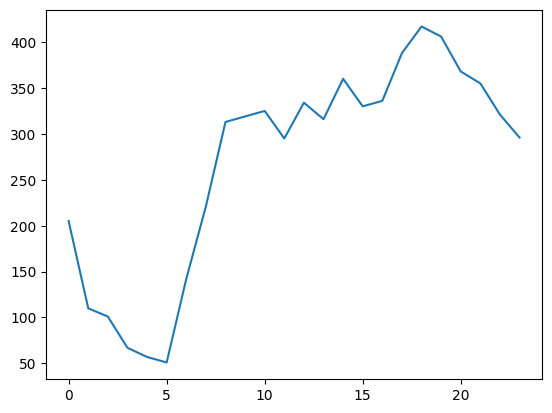

In [3]:
por_hora = taxis.groupby("hora").size()

plt.plot(por_hora.index, por_hora.values)
plt.show()

Correcta y muda: no dice qué son los ejes, usa una línea para categorías, y
**no dice cuál es la respuesta**.

### El encargo que le di al agente

```
Tengo un DataFrame `taxis` de seaborn con viajes de taxi de Nueva York.
Columnas: pickup y dropoff (fecha y hora, ya convertidas), distance, fare,
tip, total, payment, pickup_zone, pickup_borough. Ya calculé hora (0-23)
y dia (0=lunes).

OBJETIVO: quiero saber a qué hora del día hay más demanda de taxis.

RESTRICCIONES:
- usa seaborn
- va en un reporte para gerencia: tiene que entenderse sin que yo lo explique
- ejes con nombre y unidades, en español

CRITERIO DE ACEPTACIÓN:
- la hora pico marcada y legible de un vistazo
- avísame si hay horas sin ningún viaje registrado
```

Fíjense dónde está cada uno de los **cuatro fundamentos**: objetivo,
contexto, restricciones, criterio de aceptación. Y lo que salió:

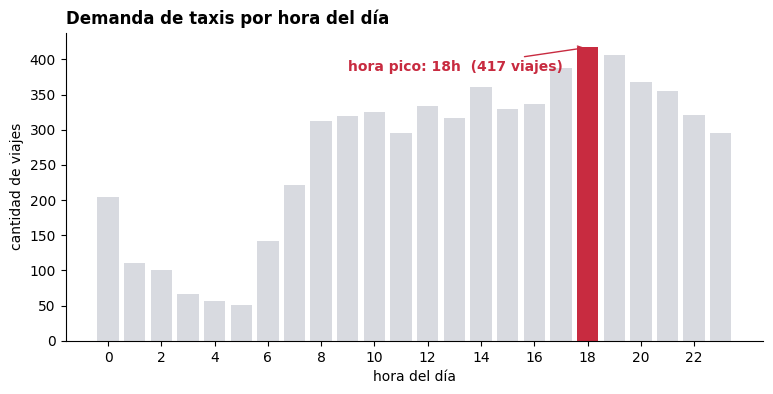

In [4]:
def grafico_demanda(datos, titulo="Demanda de taxis por hora del día"):
    '''Lo que devolvio el agente para la demo 1 (ligeramente ordenado).'''
    por_hora = datos.groupby("hora").size().reindex(range(24), fill_value=0)

    fig, ax = plt.subplots(figsize=(9, 4))
    pico = int(por_hora.idxmax())

    colores = ["#C82B40" if h == pico else "#D8DAE0" for h in por_hora.index]
    ax.bar(por_hora.index, por_hora.values, color=colores)
    ax.set_xlabel("hora del día")
    ax.set_ylabel("cantidad de viajes")
    ax.set_xticks(range(0, 24, 2))
    ax.set_title(titulo, loc="left", fontweight="bold")
    ax.annotate(f"hora pico: {pico}h  ({por_hora.max()} viajes)",
                xy=(pico, por_hora.max()),
                xytext=(pico - 9, por_hora.max() * 0.92),
                color="#C82B40", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#C82B40"))
    sns.despine(ax=ax)

    sin_viajes = int((por_hora == 0).sum())
    if sin_viajes:
        print(f"aviso: {sin_viajes} horas sin ningún viaje registrado")
    return fig


fig = grafico_demanda(taxis)
plt.show()

### Las cinco decisiones que separan las dos gráficas

1. **Barras en vez de línea** — las horas son categorías, no un continuo.
2. **Un solo color con sentido** — gris todo, rojo lo que importa.
3. **Ejes con nombre**, en el idioma del que lee.
4. **El hallazgo escrito sobre la figura** — no en la boca del presentador.
5. **Se quitó lo que sobra.**

Ninguna es programación. Las cinco son **criterio de comunicación** — por eso
las deciden ustedes, no el agente.

---

# 🛠️ Reto 1 · La flota  *(12 min)*

> **SU ENCARGO:** la gerencia de flota pregunta — **¿los vehículos mejoraron
> su consumo entre 1970 y 1982, y cuánto?**

Columnas que les sirven: `mpg` (millas por galón — **más es mejor**),
`model_year`, `origin`, `weight`.

**Armen su propio prompt** con los cuatro fundamentos y páselo al panel de
Gemini. Esta plantilla es la que se llevan del curso:

```
CONTEXTO: tengo [qué datos], con columnas [cuáles] en [qué unidades].
Es para [quién].

OBJETIVO: quiero responder [qué pregunta].

RESTRICCIONES:
- usa [qué librerías]
- [qué NO hacer]
- en español, ejes con unidades

CRITERIO DE ACEPTACIÓN:
- [qué tiene que verse o cumplirse]
- avísame si [qué problema podría tener el dato]
```

In [5]:
# los datos de SU ejercicio
mpg = sns.load_dataset("mpg")
print(f"{len(mpg)} vehículos")
mpg.head(3)

398 vehículos


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


In [6]:
# ✍️ peguen aquí lo que les devuelva el agente, y córranlo

**Cómo saber si van bien** (preguntas, no respuestas):

- ¿Su gráfica se entiende sin que ustedes hablen?
- ¿El hallazgo está *escrito* en la figura, con número?
- Este dataset tiene **valores faltantes** en una columna. ¿El agente les
  avisó, o se los tragó sin decir nada? *(si no avisó: ¿qué le faltó a su
  criterio de aceptación?)*

⏸️ **Aquí paramos y lo armamos juntos antes de seguir.**

---

# 🎬 Demo 2 · Una pregunta de operación

**La pregunta:** ¿cuándo conviene tener más gente en la calle? — la pregunta
de cualquier jefe de operaciones, y no se responde con una gráfica de una
sola variable.

### El encargo que le di

```
CONTEXTO: el mismo DataFrame `taxis`. Ya tiene hora (0-23) y
dia (0=lunes ... 6=domingo).

OBJETIVO: saber en qué combinaciones de día y hora se concentra la
demanda, para decidir turnos.

RESTRICCIONES:
- un mapa de calor con seaborn: días en filas, horas en columnas
- días en español, en orden de lunes a domingo
- nada de escalas rojo-verde (hay daltónicos en la sala)

CRITERIO DE ACEPTACIÓN:
- que se pueda señalar con el dedo el peor momento
- dime cuál es y cuántos viajes tiene
```

La restricción del rojo-verde no es estética: es que el gráfico lo pueda leer
**toda** la sala. Ese tipo de restricción solo la pone quien conoce a su
público. Lo que salió:

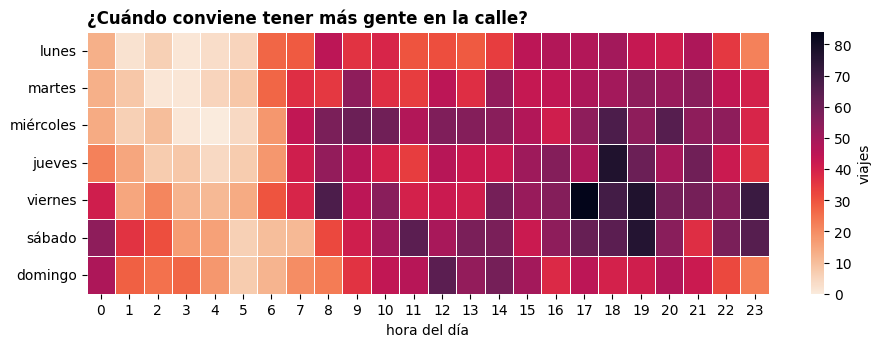

momento de más demanda: viernes a las 17h (84 viajes)


In [7]:
DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

tabla = (taxis.groupby(["dia", "hora"]).size()
         .unstack(fill_value=0)
         .reindex(index=range(7), columns=range(24), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.4))
sns.heatmap(tabla, cmap="rocket_r", ax=ax,
            cbar_kws={"label": "viajes"}, linewidths=.4, linecolor="white")
ax.set_yticklabels(DIAS, rotation=0)
ax.set_xlabel("hora del día")
ax.set_ylabel("")
ax.set_title("¿Cuándo conviene tener más gente en la calle?",
             loc="left", fontweight="bold")
plt.show()

d, h = np.unravel_index(np.argmax(tabla.values), tabla.shape)
print(f"momento de más demanda: {DIAS[d]} a las {tabla.columns[h]}h "
      f"({tabla.values.max()} viajes)")

---

# 🛠️ Reto 2 · Seguridad vial  *(12 min)*

> **SU ENCARGO:** el área de seguridad pregunta — **¿los accidentes van de la
> mano del alcohol? ¿Y en qué estados habría que priorizar una campaña?**

Columnas que les sirven: `total` (accidentados por cada 100 millones de
millas conducidas), `alcohol`, `speeding`, `abbrev` (el estado).

Su prompt, con los cuatro fundamentos. Pista de diseño: comparar dos
variables pide un tipo de gráfico; señalar estados prioritarios pide otra
cosa encima — y ambas se le pueden pedir al agente en el mismo encargo.

In [8]:
# los datos de SU ejercicio
crashes = sns.load_dataset("car_crashes")
print(f"{len(crashes)} estados")
crashes.head(3)

51 estados


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ


In [9]:
# ✍️ peguen aquí lo que les devuelva el agente, y córranlo

**Cómo saber si van bien:**

- ¿La relación entre alcohol y accidentes *se ve*, o hay que creerla de
  palabra?
- ¿Pueden señalar con el dedo **tres estados** para la campaña, y defender
  por qué esos?
- Pregunta brava: que dos cosas vayan juntas, ¿prueba que una **causa** la
  otra? ¿Qué le contestarían al gerente que lo afirme?

⏸️ **Paramos y lo discutimos.**

---

# 🎬 Demo 3 · Donde el agente falla con confianza

Hasta acá todo salió bien — y esa es justamente la trampa. Una pregunta
perfectamente razonable sobre los mismos taxis:

> **¿Los pasajeros que pagan en efectivo dejan menos propina que los que
> pagan con tarjeta?**

Es el tipo de pregunta con la que se decide una política de medios de pago.
El agente la responde en veinte segundos, con un gráfico impecable:

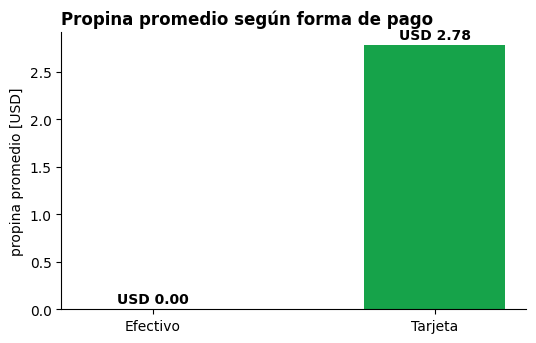

In [10]:
propinas = taxis.groupby("payment").tip.mean()

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(["Efectivo", "Tarjeta"],
       [propinas["cash"], propinas["credit card"]],
       color=["#9CA3AF", "#16A34A"], width=.5)
for i, v in enumerate([propinas["cash"], propinas["credit card"]]):
    ax.text(i, v + .06, f"USD {v:.2f}", ha="center", fontweight="bold")
ax.set_ylabel("propina promedio [USD]")
ax.set_title("Propina promedio según forma de pago", loc="left",
             fontweight="bold")
sns.despine(ax=ax)
plt.show()

La conclusión obvia — *«quien paga en efectivo nunca deja propina»* — es
**falsa**. Cuenten antes de creer:

In [11]:
efectivo = taxis[taxis.payment == "cash"]

print(f"viajes en efectivo:                  {len(efectivo)}")
print(f"de esos, con propina mayor que cero: {(efectivo.tip > 0).sum()}")

viajes en efectivo:                  1812
de esos, con propina mayor que cero: 0


**Exactamente cero.** Ese número perfecto es la pista: en datos reales, nada
es exactamente cero por casualidad.

> El taxímetro **solo registra la propina cuando va en la tarjeta**. La de
> efectivo va al bolsillo del conductor y nunca entra al sistema. La columna
> no dice «no dejó propina»: dice **«no tengo ese dato»**.

**Esto ya lo vivieron:** es el mismo error del módulo del agua — campos con
cero agua producida durante veinticinco años, porque el regulador no la
exigía hasta el año 2000. Distinto dominio, distinto país, **el mismo
error**. Y lo que lo detectó no fue una técnica: fue alguien que conocía el
negocio y dijo *«esto no puede ser»*.

### El encargo que convierte esa alarma en método

```
Antes de concluir nada de `taxis`: revisión de calidad. Filas totales y
faltantes; mínimo/máximo/ceros por columna numérica; y DIME si algún grupo
tiene SIEMPRE el mismo valor (suele ser artefacto del registro). Lista lo
que te parezca raro, aunque no estés seguro.
```

Guárdenlo: se corre con **cada dataset nuevo, antes de cualquier análisis**.

### La lista de verificación (para todo lo que devuelva un agente)

1. ¿Cuántas filas entraron y cuántas salieron?
2. ¿Hay ceros, vacíos o números redondos sospechosos?
3. ¿El resultado tiene sentido físico o de negocio?
4. ¿Qué decisión se toma con esto, y qué pasa si está mal?

Ninguna exige saber programar. Las cuatro exigen saber del negocio.

---

# 🛠️ Reto 3 · Los diamantes  *(12 min)*

> **SU ENCARGO:** van a analizar precios de diamantes... pero todavía no.
> Primero **córranle su revisión de calidad**. Este dataset esconde **al
> menos un valor físicamente imposible** — y más de uno.

Columnas: `carat` (quilates), `cut` (calidad del corte), `price` [USD], y
`x`, `y`, `z` — las **dimensiones físicas de la piedra, en milímetros**.

In [12]:
# los datos de SU ejercicio
diamonds = sns.load_dataset("diamonds")
print(f"{len(diamonds)} diamantes")
diamonds.head(3)

53940 diamantes


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


In [13]:
# ✍️ peguen aquí la revisión de calidad que les devuelva el agente

**Cómo saber si van bien:**

- ¿Qué significa físicamente que una dimensión valga **cero**? ¿Cuántas
  filas así encontraron?
- Miren el **máximo** de cada dimensión. ¿Un diamante de ese tamaño es
  creíble, o es un error de captura? *(pista: un quilate típico mide unos
  6 mm de diámetro)*
- ¿Qué harían con esas filas — borrarlas, corregirlas, preguntar? ¿Y qué le
  dirían al dueño del dato?

⏸️ **Paramos: cada grupo dice qué encontró y qué haría.**

---

# 🎬 Demo 4 · De la gráfica a una herramienta

Mientras el análisis viva en una celda, cada vez que alguien quiera ver otra
cosa **tiene que llamarlos**. Una app se la mandan y se acabó.

**Gradio** convierte una función de Python en una página web con controles, y
en Colab genera un **link público** para compartir.

> ⚠️ El link vive **mientras el cuaderno esté corriendo**. Perfecto para una
> reunión; no es un sistema permanente.

La app más chica que sirve — la función de la Demo 1, con un control:

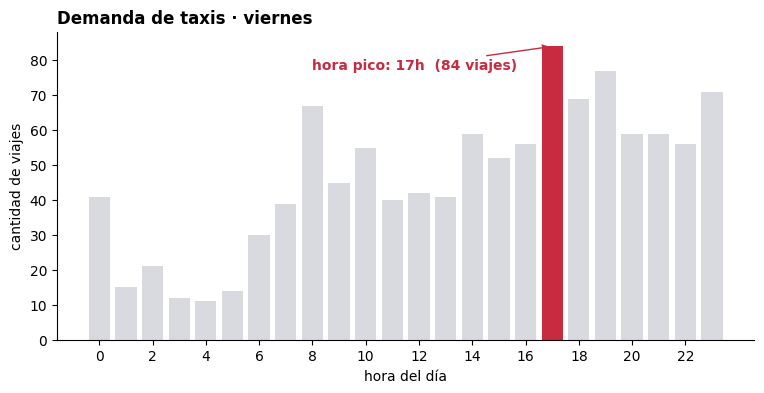

In [14]:
taxis["dia_nombre"] = taxis.dia.map(dict(enumerate(DIAS)))


def ver_demanda(dia_elegido):
    datos = taxis[taxis.dia_nombre == dia_elegido]
    return grafico_demanda(datos, titulo=f"Demanda de taxis · {dia_elegido}")


# probamos la funcion sola, antes de montar nada
_ = ver_demanda("viernes")
plt.show()

In [15]:
# En Colab esta celda publica el link. Fuera de Colab solo construye la
# interfaz (para poder verificar que el cuaderno corre entero).
try:
    import gradio as gr

    demo = gr.Interface(
        fn=ver_demanda,
        inputs=gr.Dropdown(DIAS, value="viernes", label="Día de la semana"),
        outputs=gr.Plot(label="Demanda por hora"),
        title="Demanda de taxis por día",
        description="Elija un día para ver en qué horas se concentran los viajes.")

    if EN_COLAB:
        demo.launch(share=True)      # <- aquí aparece el link público
    else:
        print("interfaz construida; en Colab esta celda abre el link")
except ImportError:
    print("gradio no está en este entorno. En Colab ya viene listo;")
    print("si hiciera falta:  !pip install gradio")

gradio no está en este entorno. En Colab ya viene listo;
si hiciera falta:  !pip install gradio


---

# 🛠️ Su turno final · La app de SU dato  *(18 min)*

> **SU ENCARGO:** elijan **uno** de sus tres datasets (`mpg`, `crashes` o
> `diamonds`) y conviertan su análisis en una **app de Gradio con link**,
> para alguien que decide.
>
> La app debe tener **al menos dos controles** (qué filtrar o comparar — lo
> deciden ustedes), mostrar **una gráfica que se entienda sola**, y **no
> caerse** si la combinación elegida no tiene datos.

Armen el prompt con los cuatro fundamentos. El caso «sin datos» va en el
**criterio de aceptación** — ese renglón es el que evita la llamada del jefe
diciendo «se me rompió».

In [16]:
# ✍️ peguen aquí su app, y córranla

**Antes de mandar el link, rómpanlo ustedes primero:**

- Elijan la combinación más rara que permitan sus controles. ¿Sobrevive?
- ¿El texto que muestra coincide con lo que muestra la gráfica?
- ¿Se lo mandarían a su jefe tal como está? Si dudan — ¿qué le falta?

⏸️ **Cierre: tres voluntarios abren su link en el proyector.**

---

# Cierre

## Lo que vimos → lo que decidimos

| Lo que vimos | Lo que decidimos |
|---|---|
| La gráfica por defecto no comunica | Cinco decisiones de diseño, siempre las mismas |
| El agente responde según cómo se le pida | Los **cuatro fundamentos** en cada encargo |
| El criterio de aceptación casi nunca se escribe | Escribirlo siempre — es lo que más cambia el resultado |
| 1.812 viajes en efectivo y **cero** propinas | Desconfiar de todo cero perfecto |
| El agente no dio ninguna señal de alarma | **Verificar siempre**: las cuatro preguntas |
| Un análisis en una celda no lo usa nadie más | Convertirlo en app con link |

## Los dos resultados negativos de hoy

1. **El agente entregó un análisis correcto con una conclusión falsa**, sin
   ninguna señal de alarma. El código estaba bien; el dato mentía.
2. En un ensayo controlado, desarrolladores experimentados fueron **19% más
   lentos** con estas herramientas — sintiéndose 20% más rápidos.

Ninguno es razón para no usarlas. Los dos son razón para **medir en vez de
confiar en la sensación**.

## Si se llevan una sola cosa

> **El agente escribe el código. Ustedes responden por el resultado.**

Escribir se volvió barato; saber si el resultado tiene sentido, no. La
habilidad de hoy no es «usar Gemini»: es **especificar bien y verificar
siempre** — y sirve con cualquier herramienta que salga el año que viene.

---

## Tarea para la próxima clase

Equipo (**máximo 3**) y problema elegidos, escritos en dos frases: **qué
duele**, y **quién decidiría distinto** con una herramienta.

Recuerden el plazo: la entrega del proyecto es **hasta el jueves de la
próxima semana** — su app con link funcionando, los prompts que usaron,
**un error del agente que ustedes cazaron**, y qué decisión se toma con la
herramienta.

---

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA
· 2026